# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import *

# Datasets loading

In [2]:
url1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df1 = pd.read_csv(url1)

# Analyse du jeu de donnée ETTH1

In [ ]:
print(df1.head())
print('*'*20)

print(df1.shape)
print('*'*20)

print("Shape :",df1.shape)
print('*'*20)

print("Columns :",df1.columns)
print('*'*20)

df1.rename(columns=lambda x: x + "_1" if x != 'date' and x[-2::] != "_1" else x, inplace=True)
print("Global information :\n", df1.info(),"\n",'-'*20,"\n")
print('*'*20)

print("NaN values for each column :\n", df1.isna().sum())
print('*'*20)

print("Number of duplicated measures :",df1.duplicated().sum())
print('*'*20)

                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000
********************
(17420, 8)
********************
Shape : (17420, 8)
********************
Columns : Index(['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='str')
********************
<class 'pandas.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  str    
 1   HUFL_1  17420 non-null  float64
 2   HULL_1  17420 non-null  float64
 3   MUFL_1  17420 non-null  float64
 4   MULL_1  17420

In [ ]:
df1['date'] = pd.to_datetime(df1['date'])
df1.set_index('date', inplace=True)
counts_per_day = df1.resample('D').size()
freq_data_day = round(counts_per_day.mean())
print("Fréquence des données (nombre de mesures/jour) :", freq_data_day)
print("Nombre de jours représentés par la série :", df1.index.max() - df1.index.min())
df1.describe().T

Fréquence des données (nombre de mesures/jour) : 24
Nombre de jours représentés par la série : 725 days 19:00:00


,count,mean,std,min,25%,50%,75%,max
HUFL_1,17420.0,7.375141,7.067744,-22.705999,5.827,8.774,11.788,23.643999
HULL_1,17420.0,2.242242,2.042342,-4.756000,0.737,2.210,3.684,10.114000
MUFL_1,17420.0,4.300239,6.826978,-25.087999,3.296,5.970,8.635,17.341000
MULL_1,17420.0,0.881568,1.809293,-5.934000,-0.284,0.959,2.203,7.747000
LUFL_1,17420.0,3.066062,1.164506,-1.188000,2.315,2.833,3.625,8.498000
LULL_1,17420.0,0.856932,0.599552,-1.371000,0.670,0.975,1.218,3.046000
OT_1,17420.0,13.324672,8.566946,-4.080000,6.964,11.396,18.079,46.007000


# Analyse de la serie temporelle univariée de la température de l'huile (target)

In [ ]:
df1 = pd.DataFrame(df1['OT_1'])

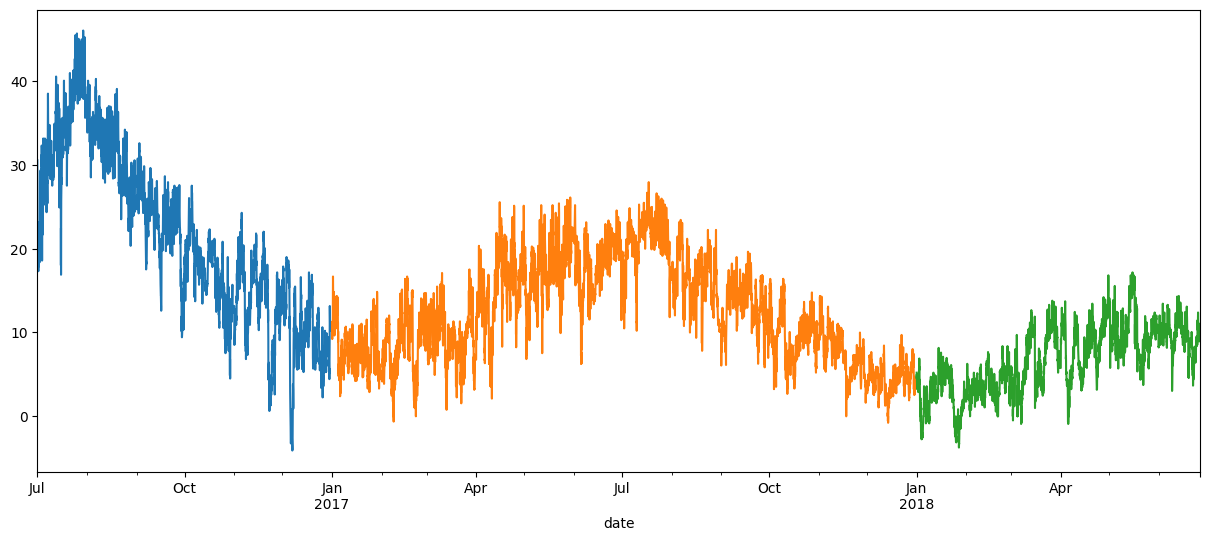

In [ ]:
plt.figure(figsize=(15,6))
df1.loc['2016', 'OT_1'].plot()
df1.loc['2017', 'OT_1'].plot()
df1.loc['2018', 'OT_1'].plot()
plt.show()

- 2016 : tendance négative, semble additif,
- 2017 : semble sans tendance, semble additif
- 2018 : tendance positive, semble additif
- Très bruité, compliqué de dégager une saisonnalité.

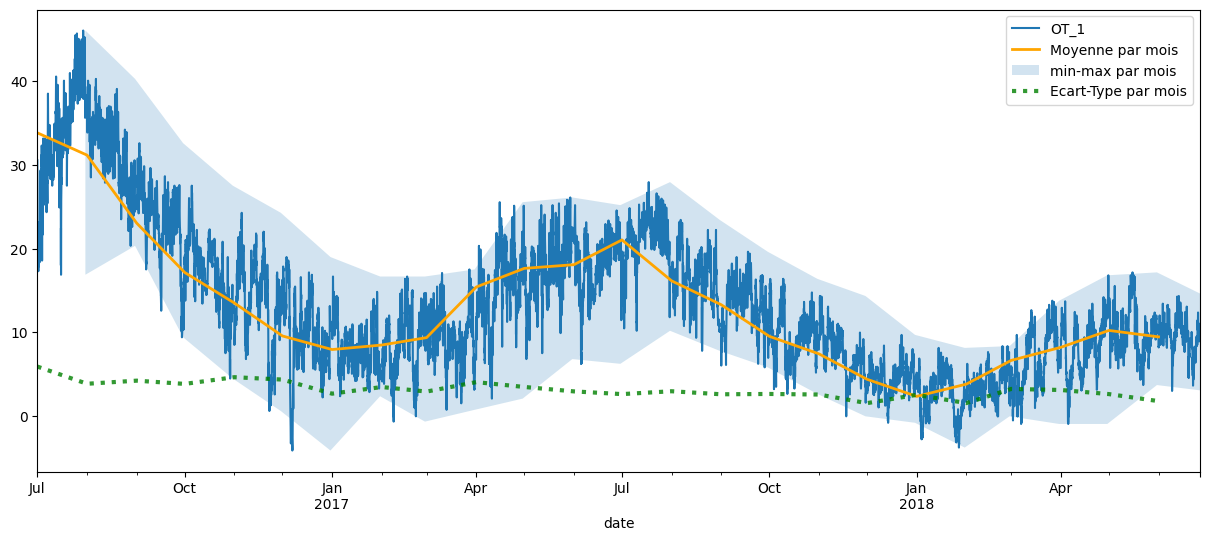

In [ ]:
plt.figure(figsize=(15,6))

df1['OT_1'].plot()
m = df1['OT_1'].resample('ME').agg(['mean','std','min','max'])

m['mean'].plot(label="Moyenne par mois", color="orange", lw=2, alpha=1)
plt.fill_between(m.index, m['max'], m['min'], alpha=0.2, label='min-max par mois')
df1['OT_1'].resample('ME').std().plot(label="Ecart-Type par mois", lw=3, ls='dotted', color="green", alpha=0.8)
plt.legend()
plt.show()

- Std semble graphiquement stable
- Mean non constante

In [ ]:
df1['OT_1'].resample('ME').agg(['mean','std']).describe().T

,count,mean,std,min,25%,50%,75%,max
mean,24.0,13.247969,8.004326,2.376293,8.160615,9.911696,17.275747,33.804284
std,24.0,3.198301,1.012513,1.569681,2.642479,2.980652,3.868336,5.930623


Mean et std varie trop, on peut désormais conclure sur la non stationnarité de la série.

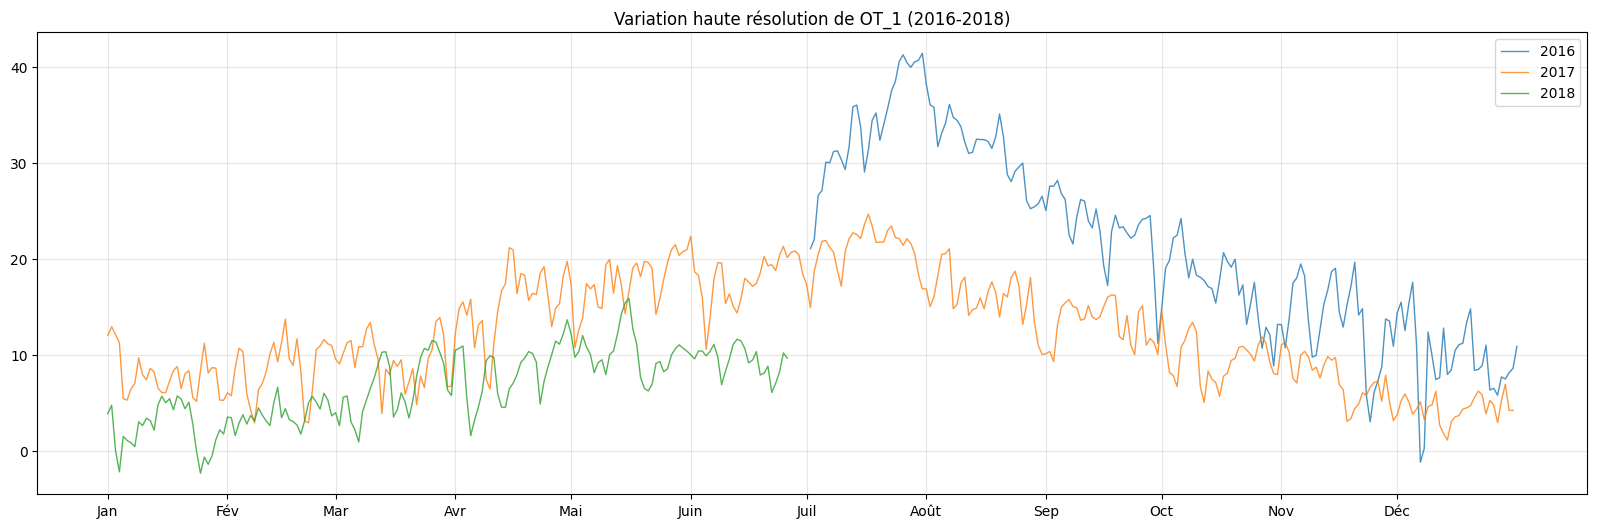

In [ ]:
df1_cycle=df1.copy()
df1_cycle = df1_cycle[['OT_1']].resample('D').mean()
# On crée une colonne pour l'année (le label) 
# et une pour le jour de l'année (l'abscisse commune)
df1_cycle['annee'] = df1_cycle.index.year
df1_cycle['jour_annee'] = df1_cycle.index.dayofyear

# 3. Tracé par groupe
plt.figure(figsize=(20, 6))

for annee, group in df1_cycle.groupby('annee'):
    plt.plot(group['jour_annee'], group['OT_1'], label=annee, linewidth=1, alpha=0.8)

# 4. Mise en forme des axes pour que ce soit lisible
# On place les labels des mois aux bons endroits (environ tous les 30 jours)
mois_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

plt.xticks(mois_ticks, mois_labels)
plt.title('Variation haute résolution de OT_1 (2016-2018)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Observation d'une tendance annuelle mais trop peu de données pour conclure. Pas de saisonnalité évidente, mais des cycles irréguliers.

## Décomposition de la série

### Composition du modèle

<Axes: xlabel='date'>

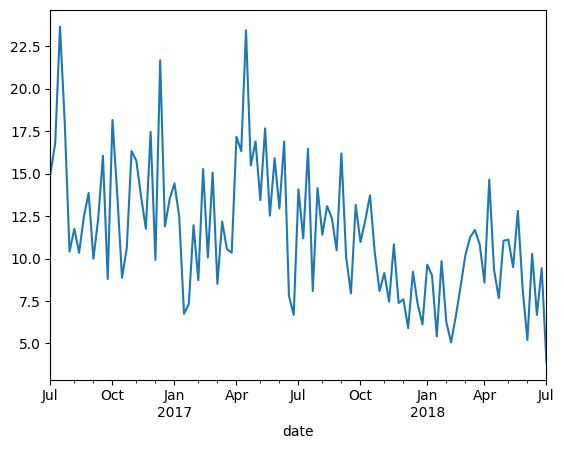

In [ ]:
df_choix_modele = df1['OT_1'].resample('W').agg(['mean','std','min','max'])
df_choix_modele["amplitude"] = df_choix_modele["max"] - df_choix_modele["min"]
df_choix_modele["amplitude"].plot()

L'amplitude par semaine n'est pas constante, on ne peut pas conclure sur la nature additive du modèle.

### Correlations

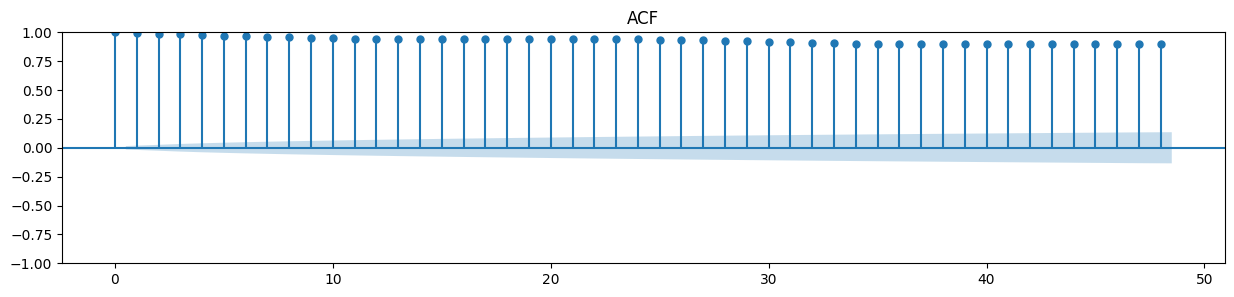

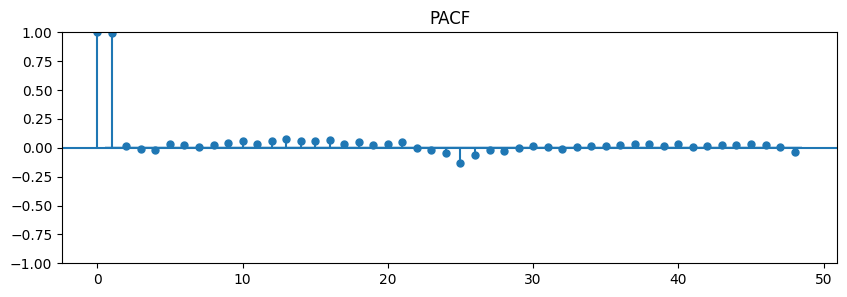

In [ ]:
plt.figure(figsize=(15, 3))
plot_acf(df1['OT_1'].dropna(), lags=freq_data_day*2, ax=plt.gca())
plt.title("ACF")


plt.figure(figsize=(10, 3))
plot_pacf(df1['OT_1'].dropna(), lags=freq_data_day*2, ax=plt.gca())
plt.title("PACF")
plt.show()

Décroissance très lente de l'ACF confirme que la série n'est pas stationnaire, et la Tendance est dominante dans le signal.

### Différenciation

In [ ]:
df1["OT_1"]

date
2016-07-01 00:00:00    30.531000
2016-07-01 01:00:00    27.787001
2016-07-01 02:00:00    27.787001
2016-07-01 03:00:00    25.044001
2016-07-01 04:00:00    21.948000
                         ...    
2018-06-26 15:00:00    10.904000
2018-06-26 16:00:00    11.044000
2018-06-26 17:00:00    10.271000
2018-06-26 18:00:00     9.778000
2018-06-26 19:00:00     9.567000
Name: OT_1, Length: 17420, dtype: float64

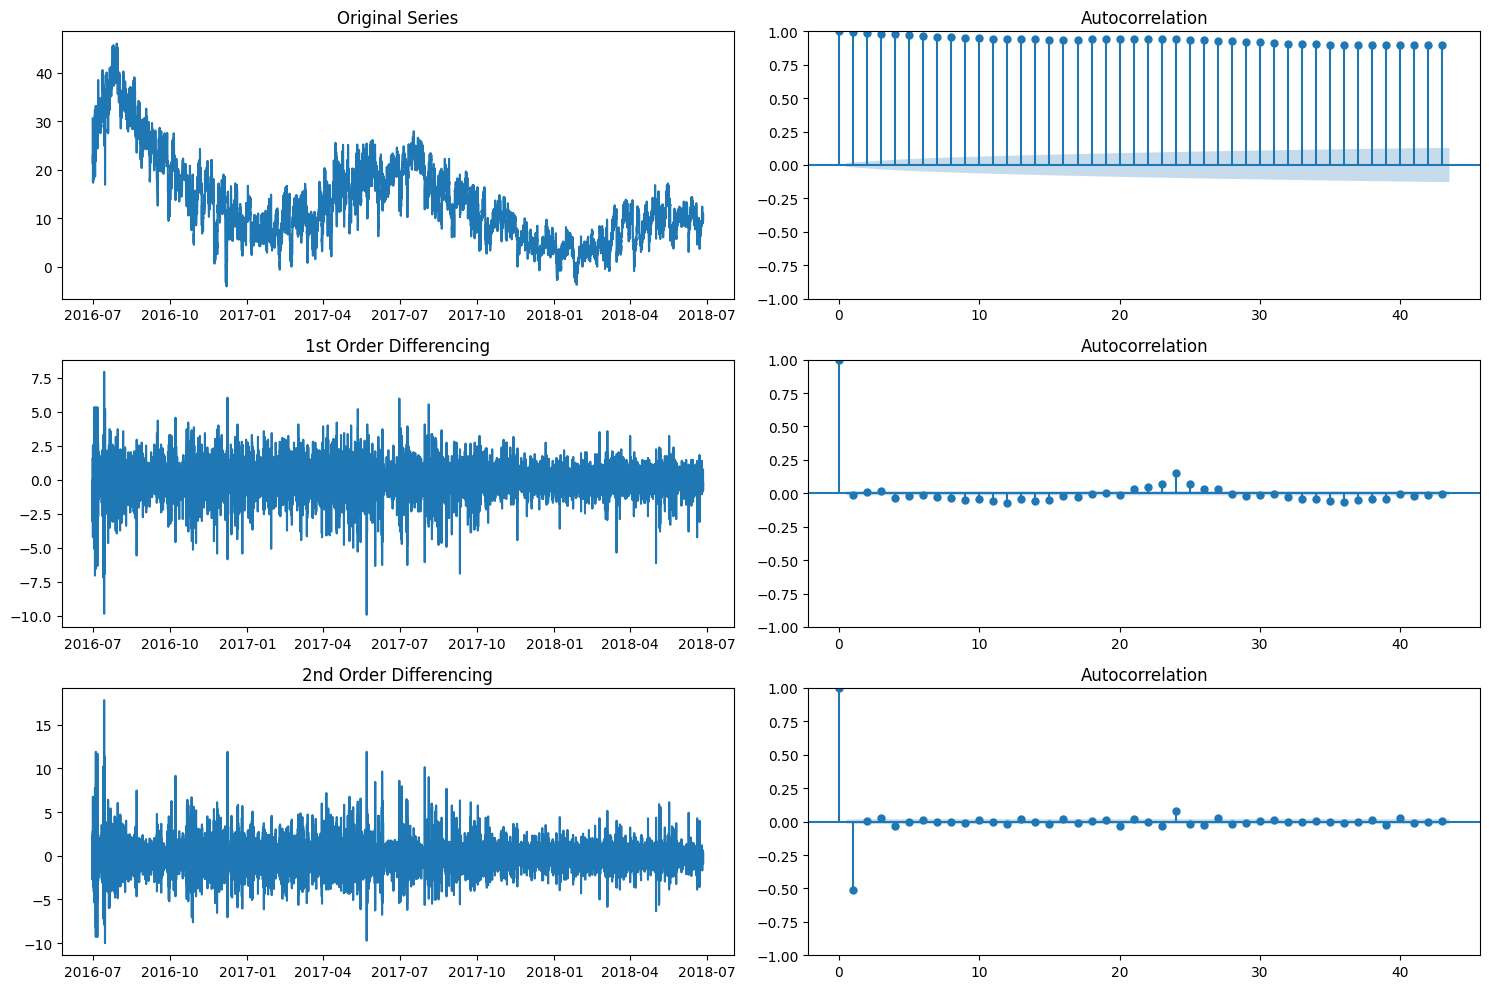

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15,10), sharex=False)
axes[0, 0].plot(df1["OT_1"])
axes[0, 0].set_title('Original Series')
plot_acf(df1["OT_1"], ax=axes[0, 1])

axes[1, 0].plot(df1["OT_1"].diff())
axes[1, 0].set_title('1st Order Differencing')
plot_acf(df1["OT_1"].diff().dropna(), ax=axes[1, 1])

axes[2, 0].plot(df1["OT_1"].diff().diff())
axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df1["OT_1"].diff().diff().dropna(), ax=axes[2, 1])

plt.tight_layout()
plt.show()

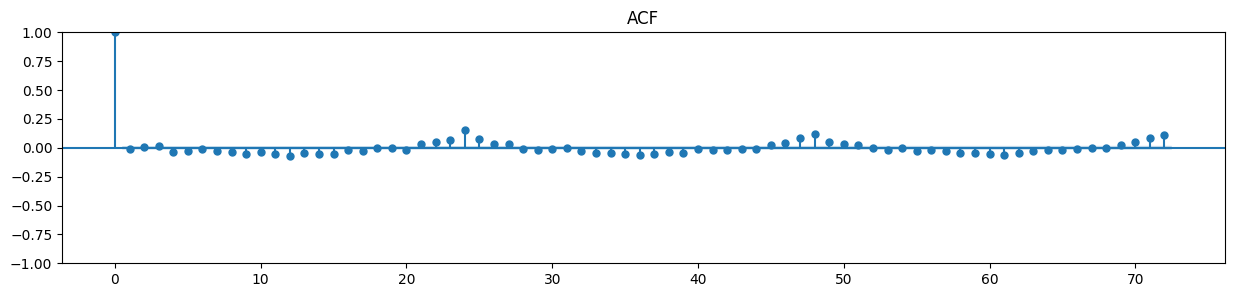

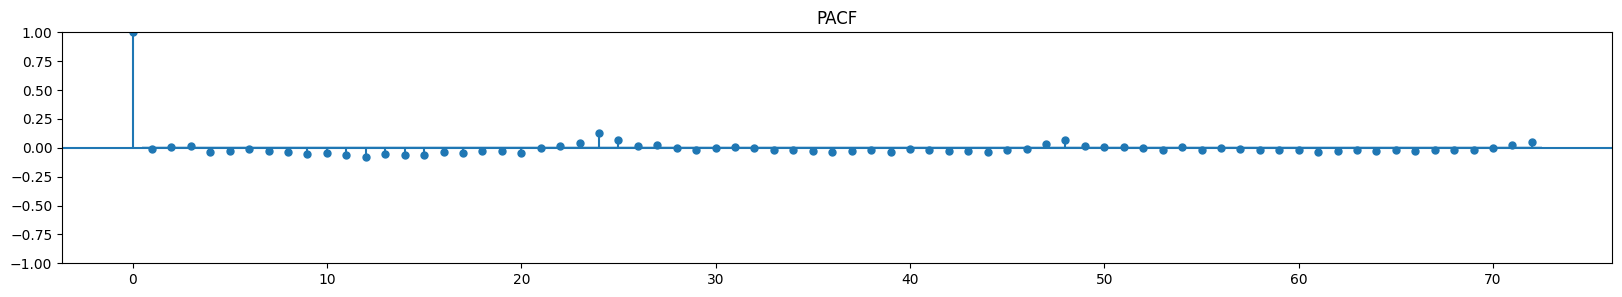

In [ ]:
diff_df1 = df1.copy()
diff_df1["OT_1"] = diff_df1["OT_1"].diff(1) #detrending

plt.figure(figsize=(15, 3))
plot_acf(diff_df1["OT_1"].dropna(), lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("ACF")


plt.figure(figsize=(20, 3))
plot_pacf(diff_df1["OT_1"].dropna(), lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("PACF")
plt.show()

On a identifié notre saisonnalité qui est journalière (24= 24h = 1 jour)

### Classique & STL decompositions

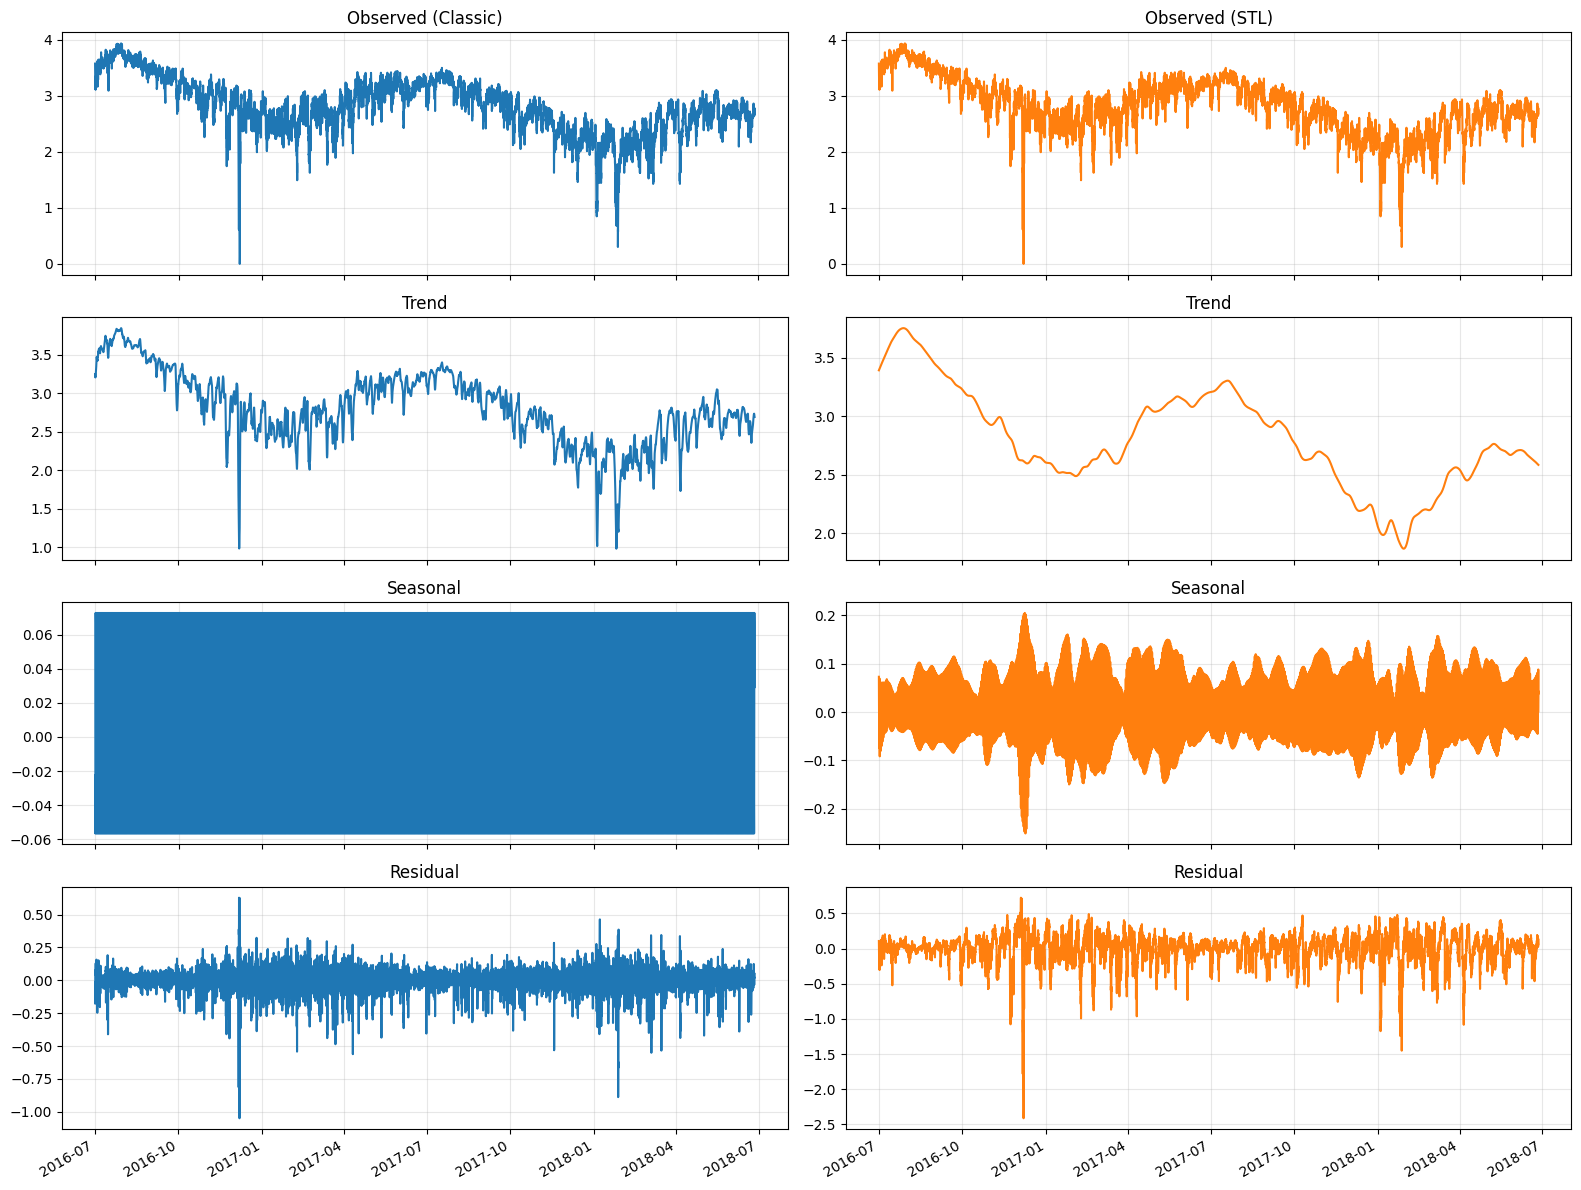

In [ ]:
full_range = pd.date_range(start=df1.index.min(), end=df1.index.max(), freq='h')
data_reindexed = df1.reindex(full_range)
data_filled = data_reindexed['OT_1'].interpolate(method='linear').ffill().bfill()

# Shift + Log, valeur minimale soit à 1.0 (log(1) = 0)
shift_value = abs(data_filled.min()) + 1.0
data_transformed = np.log(data_filled + shift_value)

period = freq_data_day # journalière

decomp_classic = seasonal_decompose(data_transformed, model='additive', period=int(period))

# STL (Robuste)
# seasonal = 17 est une valeur standard pour lisser la saisonnalité
# trend = 169 (on lisse sur environ une semaine : 24*7 + 1 pour avoir un impair)
stl = STL(data_transformed, period=int(period), seasonal=17, trend=freq_data_day*28+1).fit()
#seasonal : sur combien de jours (environ) l'algorithme "moyenne" le motif
#   - Grande valeur (ex: 101),  la saisonnalité sera très rigide (elle ressemblera à celle de seasonal_decompose).
#   - Petite valeur (ex: 7),    la saisonnalité changera très vite d'un jour à l'autre, capturant même des variations météo soudaines.


idx = data_transformed.index
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 12))

col0 = [data_transformed, decomp_classic.trend, decomp_classic.seasonal, decomp_classic.resid]
titles0 = ["Observed (Classic)", "Trend", "Seasonal", "Residual"]

col1 = [stl.observed, stl.trend, stl.seasonal, stl.resid]
titles1 = ["Observed (STL)", "Trend", "Seasonal", "Residual"]

for i in range(4):
    axes[i, 0].plot(idx, col0[i], color='tab:blue')
    axes[i, 0].set_title(titles0[i])
    
    axes[i, 1].plot(idx, col1[i], color='tab:orange')
    axes[i, 1].set_title(titles1[i])
    
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)

# Nettoyage des labels de date pour ne pas surcharger
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

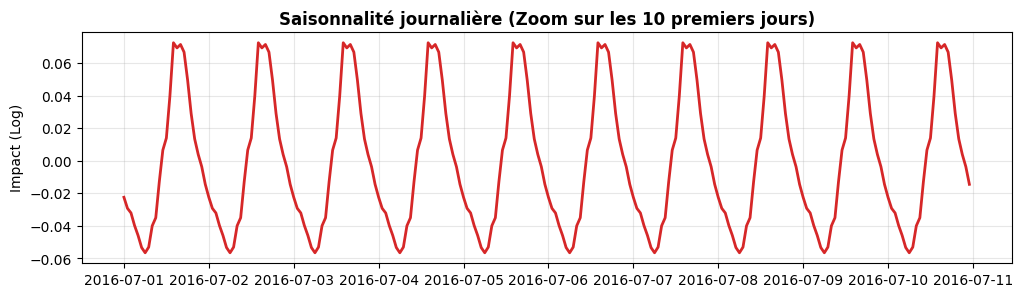

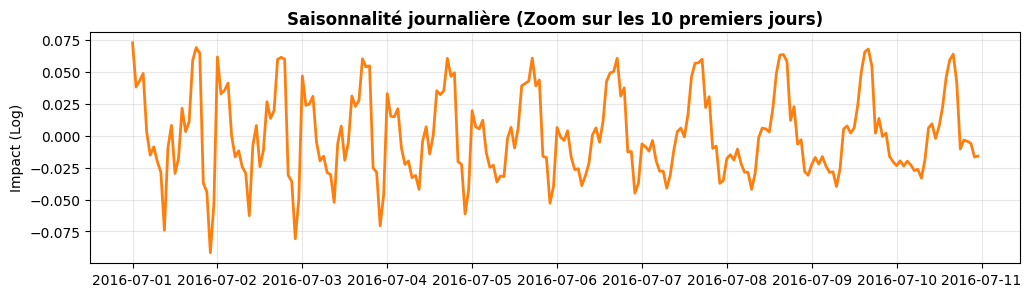

In [ ]:
# Zoom sur les 10 premiers jours (24 points * 10 = 240)
plt.figure(figsize=(12,3))
plt.plot(decomp_classic.seasonal[:240], color='tab:red', linewidth=2)
plt.title("Saisonnalité journalière (Zoom sur les 10 premiers jours)", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylabel("Impact (Log)")
plt.show()

# Zoom sur les 10 premiers jours (24 points * 10 = 240)
plt.figure(figsize=(12, 3))
plt.plot(stl.seasonal[:240], color='tab:orange', linewidth=2)
plt.title("Saisonnalité journalière (Zoom sur les 10 premiers jours)", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylabel("Impact (Log)")
plt.show()

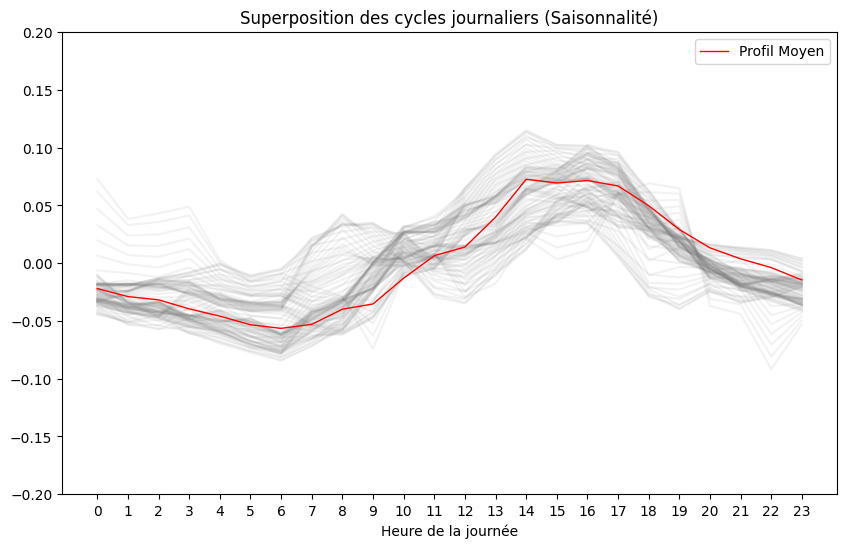

In [ ]:
# On reformate la saisonnalité en matrice (Jours x 24h). On s'assure d'avoir un nombre entier de jours
n_days = len(stl.seasonal) // 24
seasonal_matrix = stl.seasonal[:n_days*24].values.reshape(-1, 24)

plt.figure(figsize=(10, 6))
for i in range(min(n_days, 100)): # On trace les 100 premiers jours pour ne pas ramer
    plt.plot(seasonal_matrix[i, :], color='gray', alpha=0.1)

plt.plot(seasonal_matrix.mean(axis=0), color='red', linewidth=1, label='Profil Moyen')
plt.title("Superposition des cycles journaliers (Saisonnalité)")
plt.xticks(range(0, 24))
plt.ylim([-0.2, 0.2])
plt.xlabel("Heure de la journée")
plt.legend()
plt.show()

## Tests de stationnarité

# Etude de la stationnarité de la série

D'après toutes nos informations précédentes, la série n'est pas stationnaire. Vérifions le par des tests.

In [ ]:
def stationarity_tests(dataframe, target: str):
    # "Est-ce que la série s'éloigne à l'infini (marche aléatoire) ou revient-elle toujours vers une moyenne ?"
    # Stationnarité vs Saisonnalité : Une série peut être "Mean-Reverting" (elle revient vers sa moyenne, donc ADF OK) tout en ayant une structure de corrélation énorme (ACF qui décroît lentement) à cause de cycles longs.
    data = dataframe[target].dropna()
    
    result_adf = adfuller(data)
    adf_p = result_adf[1]
    
    result_kpss = kpss(data, regression='c', nlags="auto")
    kpss_p = result_kpss[1]

    print(f'p-value ADF : {adf_p:.4f}')
    print(f'p-value KPSS : {kpss_p:.4f}')

    # --- LOGIQUE CORRIGÉE ---
    if (kpss_p > 0.05) and (adf_p < 0.05):
        # ADF rejette non-stationnarité ET KPSS ne rejette pas stationnarité
        print("\nVerdict : La série est strictement STATIONNAIRE.")
        
    elif (kpss_p < 0.05) and (adf_p > 0.05):
        # ADF échoue à rejeter racine unitaire ET KPSS rejette stationnarité
        print("\nVerdict : La série n'est PAS STATIONNAIRE (Racine unitaire, différencier pour detrend).")
        
    elif (kpss_p < 0.05) and (adf_p < 0.05):
        # Les deux rejettent leur H0 !
        print("\nVerdict : Série STATIONNAIRE EN TENDANCE (Trend-Stationary, detrend par régression).")
        print("Elle revient vers sa moyenne une fois la tendance retirée.")
        
    elif (kpss_p > 0.05) and (adf_p > 0.05):
        # Aucun ne rejette son H0 !
        print("\nVerdict : AMBIGUÏTÉ. Probablement une série avec une faible variance ou manque de données.")

In [ ]:
stationarity_tests(df1, "OT_1")

p-value ADF : 0.0083
p-value KPSS : 0.0100

Verdict : Série STATIONNAIRE EN TENDANCE (Trend-Stationary, detrend par régression).
Elle revient vers sa moyenne une fois la tendance retirée.


/tmp/ipykernel_7068/1923553798.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(data, regression='c', nlags="auto")


Graphiquement lors de la décomposition, on a vu que la tendance ce semble pas stationnaire dans les limites des mesures, on conclut que la série n'est pas significativement stationnaire à 5%

Puisque la série est dite stationnaire en tendance, il faudrait detrend par régression car tendance déterministe, mais ici fait par simplicité une différenciation d'ordre 1.

In [ ]:
def plot_rolling_stats(series, window=freq_data_day, title="Analyse de Stationnarité"):
    rolmean = series.rolling(window=window).mean()
    rolstd = series.rolling(window=window).std()
    plt.plot(series, color='blue', alpha=0.3, label='Original')
    plt.plot(rolmean, color='red', label='Moyenne Mobile')
    plt.plot(rolstd, color='black', label='Écart-type Mobile')
    plt.legend(loc='best')
    plt.title(title)
    plt.grid(True, alpha=0.3)

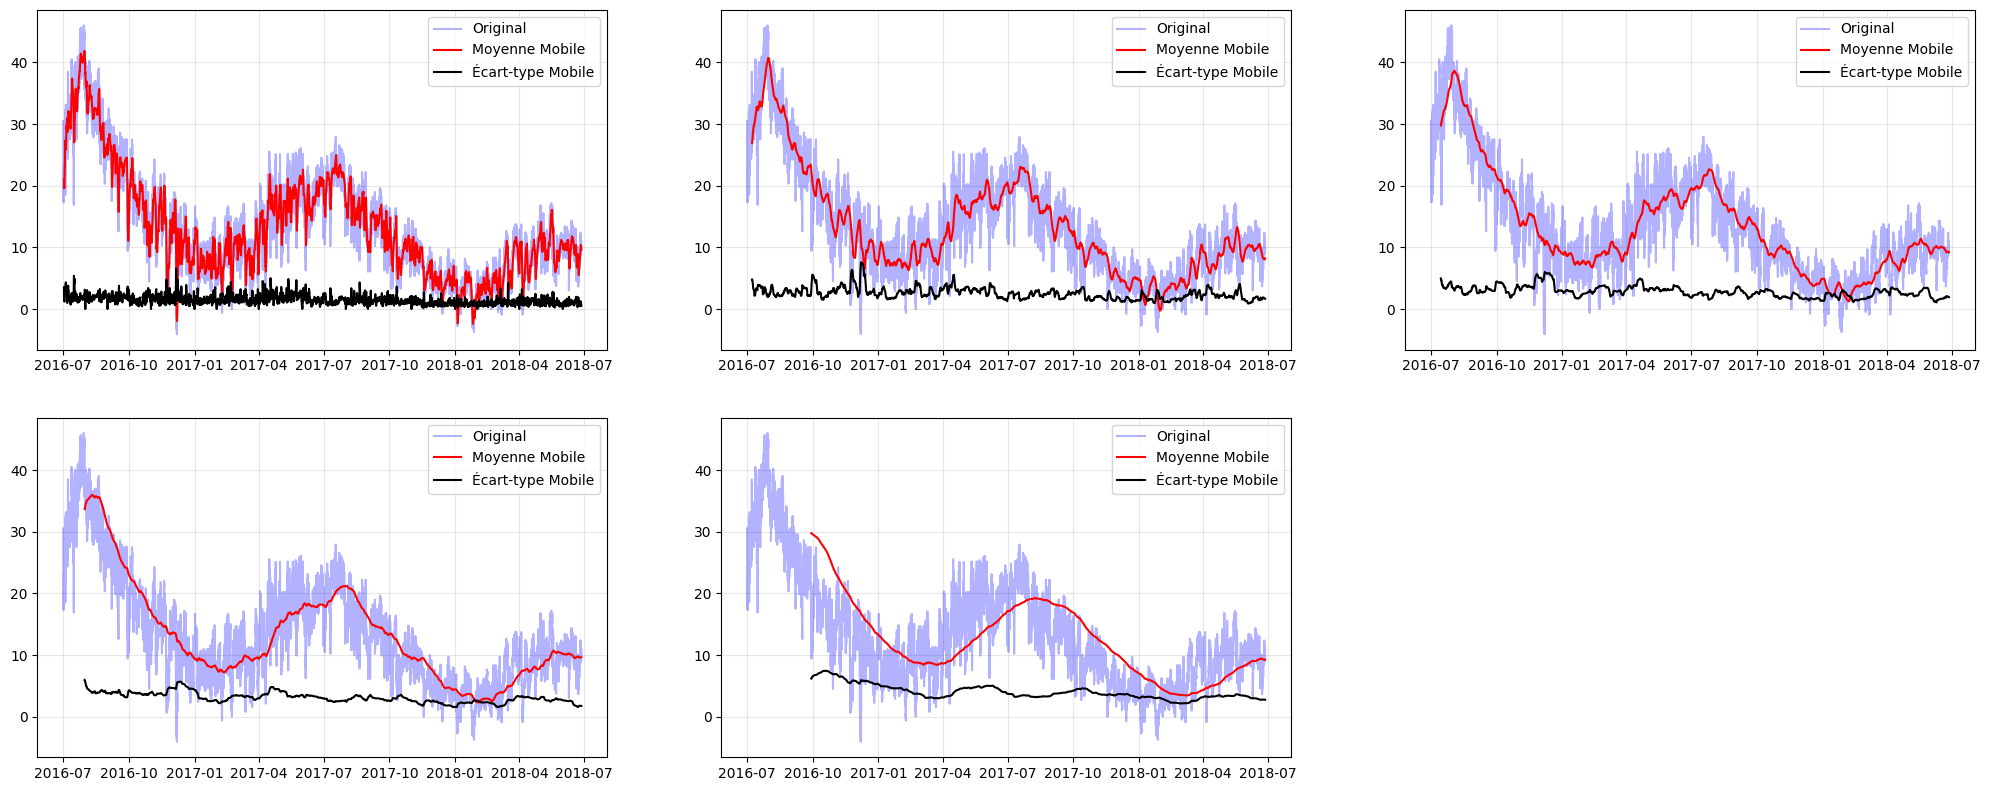

In [ ]:
win = [1, 7, 14, 30, 90]
fig = plt.figure(figsize=(25,15))

for i in range(len(win)):
    ax = fig.add_subplot(3, 3, i+1)
    plot_rolling_stats(df1['OT_1'], window=freq_data_day*win[i], title="")
    ax.legend()
plt.tight_layout
plt.show()

p-value ADF : 0.0000
p-value KPSS : 0.1000

Verdict : La série est strictement STATIONNAIRE.


/tmp/ipykernel_7068/1923553798.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(data, regression='c', nlags="auto")


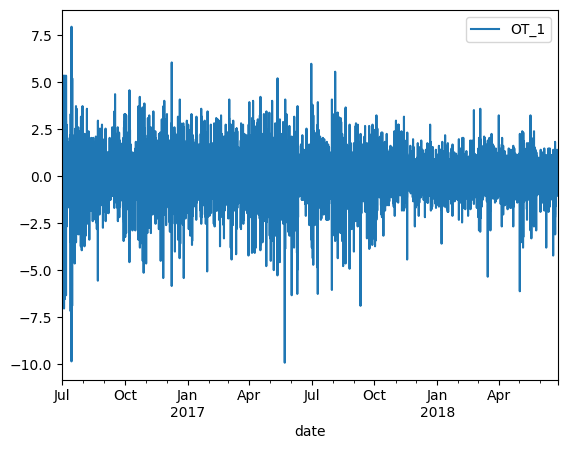

In [ ]:
diff_df1.plot()
stationarity_tests(diff_df1, "OT_1")

## Identification du modèle

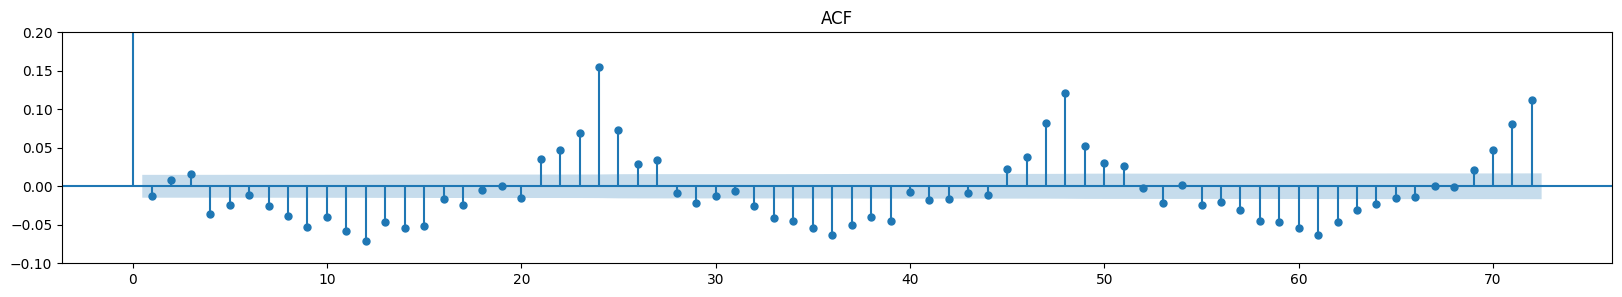

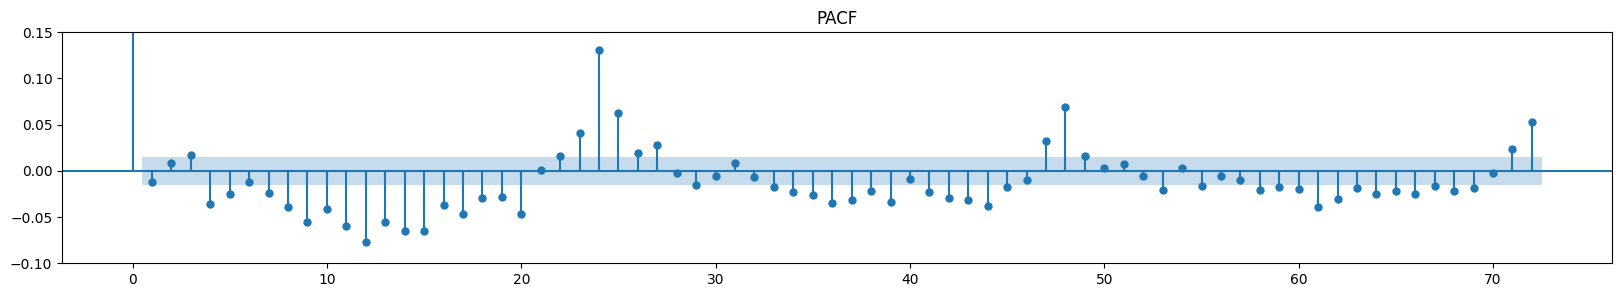

In [ ]:
plt.figure(figsize=(20, 3))
plot_acf(diff_df1["OT_1"].dropna(), lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("ACF")
plt.ylim([-0.1, 0.20])

plt.figure(figsize=(20, 3))
plot_pacf(diff_df1["OT_1"].dropna(), lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("PACF")
plt.ylim([-0.1, 0.15])
plt.show()

Analyse des corrélogrammes : 
- ACF : Tend vite vers 0 mais remonte (AR), disons qu'elle s'annule après l'ordre q = 5 (MA)
- PACF : Disons s'annule après ordre p=5, tend vite vers 0 mais remonte
- Saisonnalité en lag = t+24

Modèle SARIMA, mais au vu de la complexité que les corrélogrammes laissent sous-entendre, on va tenter une approche de désaisonnalité.

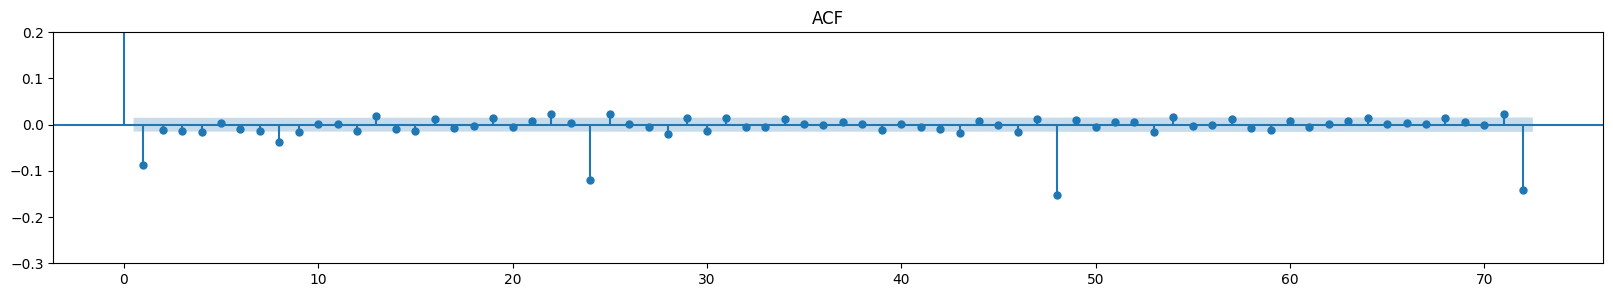

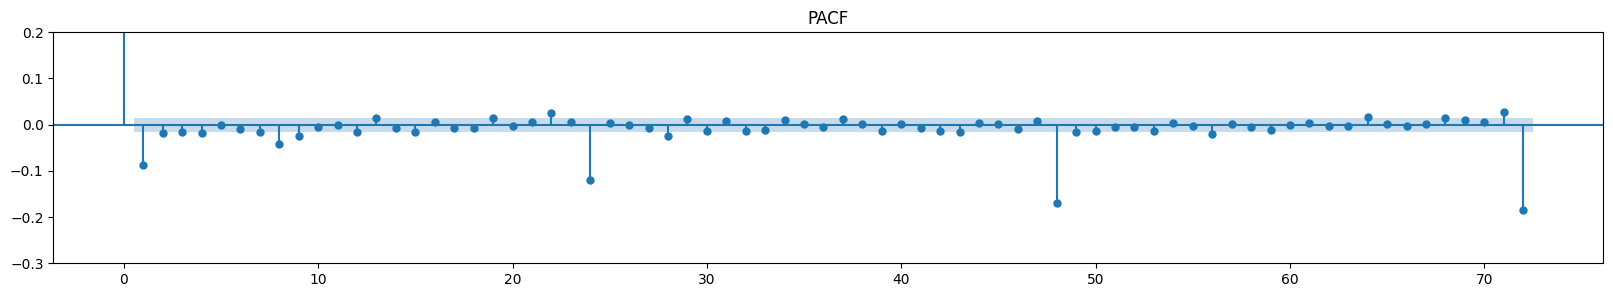

In [ ]:
data_desais = data_transformed - stl.seasonal
data_arma_ready = data_desais.diff().dropna()

plt.figure(figsize=(20, 3))
plot_acf(data_arma_ready, lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("ACF")
plt.ylim([-0.3, 0.20])

plt.figure(figsize=(20, 3))
plot_pacf(data_arma_ready, lags=freq_data_day*3, ax=plt.gca()) #hebdo
plt.title("PACF")
plt.ylim([-0.3, 0.20])
plt.show()

Analyse des corrélogrammes : 
- Saisonnalité résiduelle
- ACF : Tend vite vers 0 (AR), s'annule après l'ordre q = 1 (MA)
- PACF : S'annule après ordre p=1, tend vite vers 0
- ACF comme PACF tendent vers 0 exponentiellement

Modèle ARIMA en ignorant les pics de saisonnalité "faible" ou un petit modèle SARIMA

ARIMA(1,0,1)
SARIMA(1,0,1)(1,0,1)_24

## Estimation du modèle

In [ ]:
n_test = 24
model1 = SARIMAX(data_arma_ready.iloc[:-n_test].values, order=(1,0,1))
res1 = model1.fit(disp=False)
print(res1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17395
Model:               SARIMAX(1, 0, 1)   Log Likelihood               25831.132
Date:                Thu, 26 Mar 2026   AIC                         -51656.263
Time:                        15:49:17   BIC                         -51632.972
Sample:                             0   HQIC                        -51648.591
                              - 17395                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1529      0.047      3.253      0.001       0.061       0.245
ma.L1         -0.2421      0.046     -5.269      0.000      -0.332      -0.152
sigma2         0.0030    1.2e-05    250.247      0.0

Analyse du modèle ARIMA(1,1,1):
- Toutes les composantes sont significativement utiles à 5%
- Les critères d'informations du modèle à minimiser (AIC,BIC) sont très faibles
- Ljung-Box : H0 Les résidues sont indépendants (bruit blanc) ==> p-value < 5%, on rejette H0 (PAS OK)
- Jarque-Bera : Prob(JB) = 0.000 ==> p-value < 5%, on rejette H0 des résidus normaux (PAS OK)
- Heteroskedasticity : Prob(H) = 0.05 ==> p-value = 5%, on ne rejette pas mais on accepte pas forcément H0 qui est l'homoscedasticité. La variance de fin de serie diverge de 5% // au début, mais sur +17k points, le test devient très sensible, donc c'est OK

     count     mean      std       min       25%       50%       75%       max
0  17395.0 -0.00005  0.05481 -0.625152 -0.021457  0.000823  0.023509  0.836465


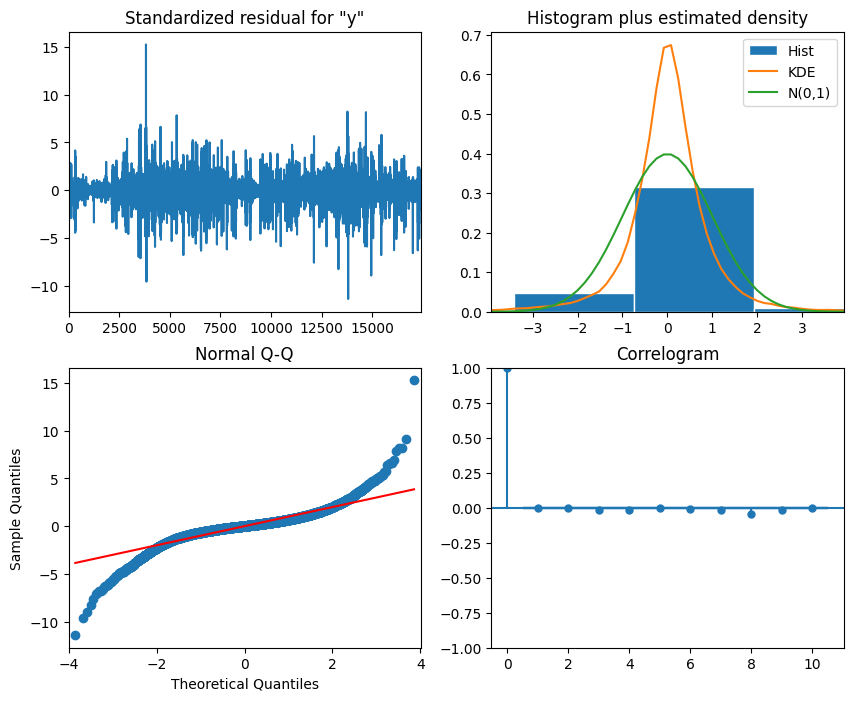

In [ ]:
print(pd.DataFrame(res1.resid).describe().T)
res1.plot_diagnostics(figsize=(10, 8))
plt.show()

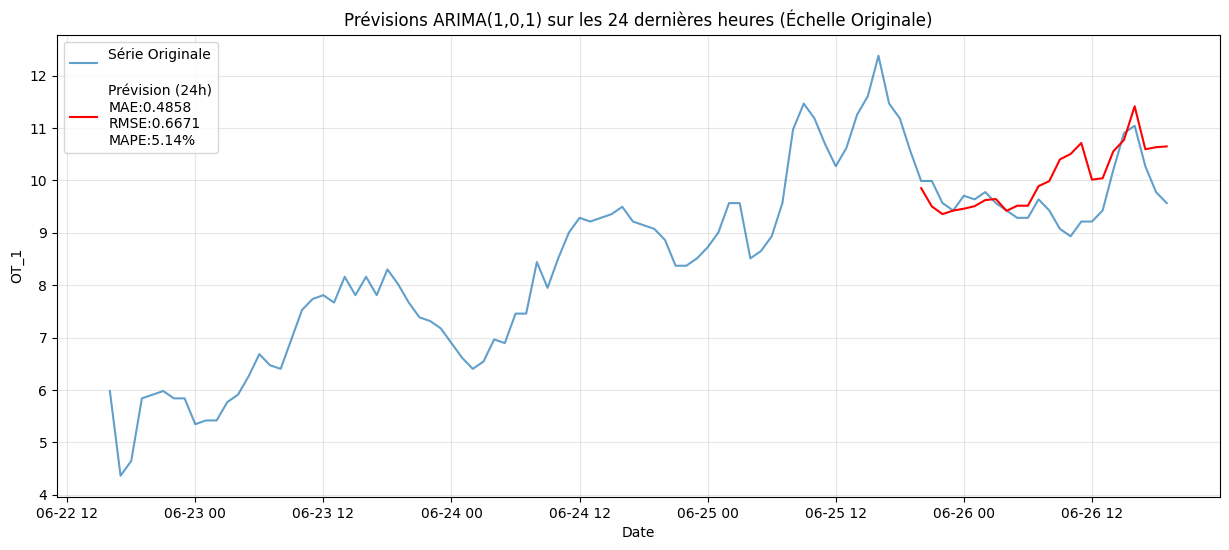

--- Performances sur 24h ---
MAE	: 0.4858
RMSE	: 0.6671
MAPE	: 5.14%


In [ ]:
train_data = data_arma_ready.iloc[:-n_test]
test_actuals = df1['OT_1'].iloc[-n_test:] #série originale

model_fit = SARIMAX(train_data, order=(1, 0, 1)).fit(disp=False)
forecast_diff = model_fit.forecast(steps=n_test)

# --- ÉTAPE A : Inverser la différenciation ---
# On récupère la dernière valeur connue de data_desais avant le test
last_val_desais = data_desais.iloc[-(n_test + 1)]
forecast_desais = forecast_diff.cumsum() + last_val_desais
# --- ÉTAPE B : Réintroduire la saisonnalité ---
# On récupère les composantes saisonnières correspondantes aux dates du test
seasonal_part = stl.seasonal.iloc[-n_test:]
forecast_log = forecast_desais + seasonal_part.values
# --- ÉTAPE C : Inverser le Log et le Shift ---
forecast_final = np.exp(forecast_log) - shift_value



rmse = np.sqrt(mean_squared_error(test_actuals, forecast_final))
mape = np.mean(np.abs((test_actuals - forecast_final) / test_actuals)) * 100
mae  = mean_absolute_error(test_actuals, forecast_final)
# ********** PLOT ***********
plt.figure(figsize=(15, 6))

plt.plot(df1.index[-100:], df1['OT_1'][-100:], label='Série Originale\n', color='tab:blue', alpha=0.7)
plt.plot(test_actuals.index, forecast_final, label=f'Prévision ({n_test}h)\nMAE:{mae:.4f}\nRMSE:{rmse:.4f}\nMAPE:{mape:.2f}%', color='red', linewidth=1.5)

plt.title(f"Prévisions ARIMA(1,0,1) sur les {n_test} dernières heures (Échelle Originale)")
plt.xlabel("Date")
plt.ylabel("OT_1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
result_table = pd.DataFrame(columns=["Model","Train_size","Val_size","Test_size", "MAE","RMSE","MAPE(%)"])
scores_model = {"Model":"First ARIMA", "Train_size":train_data.shape[0], "Val_size":0, "Test_size":n_test, "MAE":mae, "RMSE":rmse, "MAPE(%)":mape}
result_table.loc[len(result_table)] = scores_model

### Test d'un modèle SARIMA sur données brutes

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               OT_1   No. Observations:                11396
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -13351.657
Date:                            Thu, 26 Mar 2026   AIC                          26713.313
Time:                                    16:52:59   BIC                          26749.996
Sample:                                03-08-2017   HQIC                         26725.653
                                     - 06-25-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9510      0.003    335.199      0.000       0.945       0.957
ma.L1         -0.9946      0.001   

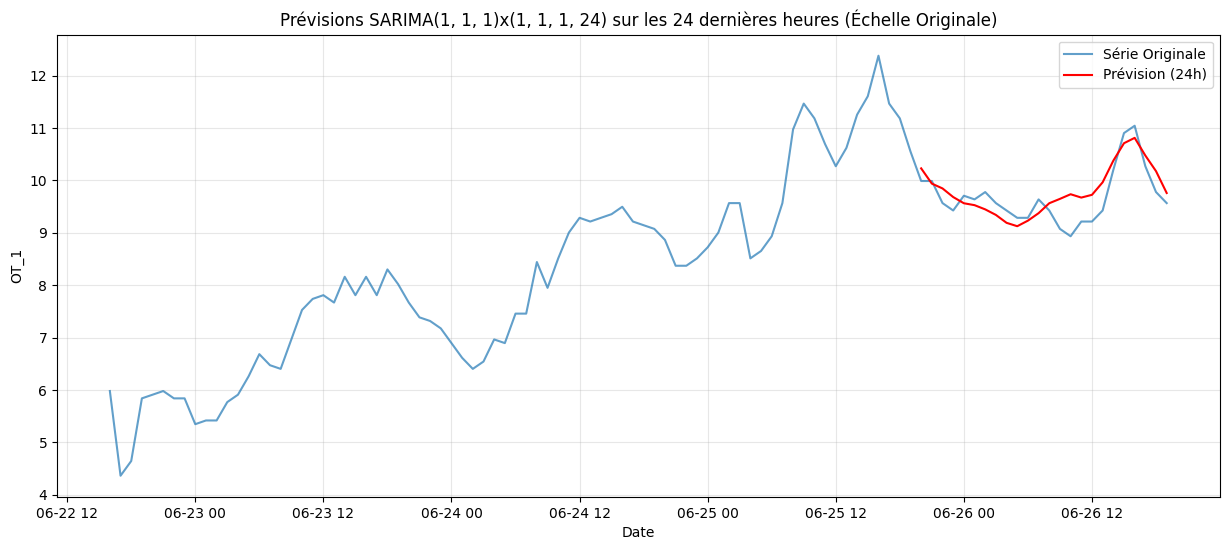

--- Performances sur 24h ---
MAE	: 0.2820
RMSE	: 0.3331
MAPE	: 2.96%


In [ ]:
testsize=24
start_train = 6000
train = df1.iloc[start_train:-testsize] # On coupe des vieilles données car explosion de la RAM avec la saisonnalité à 24
model = SARIMAX(train["OT_1"],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 24),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)
print(result.summary())

forecast = result.forecast(steps=testsize)

plt.figure(figsize=(15, 6))

plt.plot(df1.index[-100:], df1['OT_1'][-100:], label='Série Originale', color='tab:blue', alpha=0.7)
plt.plot(forecast.index, forecast, label=f'Prévision ({testsize}h)', color='red', linewidth=1.5)

plt.title(f"Prévisions SARIMA(1, 1, 1)x(1, 1, 1, 24) sur les {testsize} dernières heures (Échelle Originale)")
plt.xlabel("Date")
plt.ylabel("OT_1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rmse_AIC = np.sqrt(mean_squared_error(df1.iloc[-testsize:], forecast))
mae_AIC  = mean_absolute_error(df1.iloc[-testsize:], forecast)
mape_AIC = np.mean(np.abs((df1.iloc[-testsize:]['OT_1'] - forecast) / df1.iloc[-testsize:]['OT_1'])) * 100


print(f"--- Performances sur {testsize}h ---")
print(f"MAE\t: {mae_AIC:.4f}")
print(f"RMSE\t: {rmse_AIC:.4f}")
print(f"MAPE\t: {mape_AIC:.2f}%")

## Détermination d'un modèle par GridSearch

Pour ajuster un modèle SARIMA aux données d'une série temporelle, il faut déterminer le jeu de paramètres (p,d,q)(P,D,Q)s optimaux. On peut faire de la recherche sur grille qui consiste à tester de manière itérative plusieurs valeurs possibles des paramètres et d'évaluer les modèles en utilisant des critères tels que AIC ou BIC.
On utilisera nous le critère d'information Akaike (AIC) qui mesure la qualité relative des modèles statistiques pour un ensemble d'observations donné. À partir d'un ensemble de modèles, le critère AIC permet d'estimer la qualité de chacun des modèles par rapport aux autres. Cela permet donc de sélectionner des modèles. Intuitivement, le critère AIC mesure le compromis entre la qualité de l'ajustement du modèle aux observations fournies et la complexité du modèle
Le meilleur modèle est celui qui minimise le critère AIC. À titre de comparaison, on regarde aussi selon le critère BIC.

In [27]:
# from statsmodels.tsa.statespace.sarimax import *
# from tqdm import tqdm
# import itertools

# import warnings
# warnings.filterwarnings(action='ignore') #'once' pour afficher le warning une seule fois

# # on génère toutes les combinaisons possibles des paramèters
# p = d = q = P = D = Q = range(2)
# params = list(itertools.product(p, d, q, P, D, Q))

# # on initialise nos paramètres optimaux
# best_aic, best_bic = np.inf, np.inf
# best_params_AIC, best_params_BIC = None, None
# best_seasonal_AIC, best_seasonal_BIC = None, None

# for p,d,q,P,D,Q in tqdm(params):
#     try:
#         # On définit le modèle
#         tmp_model = SARIMAX(train["OT_1"],
#                             order=(p, d, q),
#                             seasonal_order=(P, D, Q, 24),
#                             enforce_stationarity=True,
#                             enforce_invertibility=True)
        
#         # disp=False et low_memory=True pour économiser la RAM
#         res = tmp_model.fit(disp=False, low_memory=True)

#         if res.aic < best_aic:
#             best_aic = res.aic
#             best_params_AIC = (p, d, q)
#             best_seasonal_AIC = (P, D, Q, 24)

#         if res.bic < best_bic:
#             best_bic = res.bic
#             best_params_BIC = (p, d, q)
#             best_seasonal_BIC = (P, D, Q, 24)
            
#     except Exception as e:
#         # On ignore les modèles qui ne convergent pas
#         continue


# print(f"Meilleur AIC: {best_aic} pour {best_params_AIC}x{best_seasonal_AIC}")
# print(f"Meilleur BIC: {best_bic} pour {best_params_BIC}x{best_seasonal_BIC}")

In [28]:
final_model_AIC = SARIMAX(train["OT_1"], order=(1, 1, 1), seasonal_order=(1, 0, 1, 24)).fit()
print(final_model_AIC.summary())

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                               OT_1   No. Observations:                11396
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood              -13387.075
Date:                            Mon, 02 Mar 2026   AIC                          26784.150
Time:                                    17:19:49   BIC                          26820.855
Sample:                                03-08-2017   HQIC                         26796.494
                                     - 06-25-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9554      0.003    378.947      0.000       0.950       0.960
ma.L1         -0.9961      0.001  -

     count      mean       std       min       25%       50%       75%    max
0  11396.0 -0.000535  0.787684 -9.149953 -0.331865  0.010898  0.367993  8.442


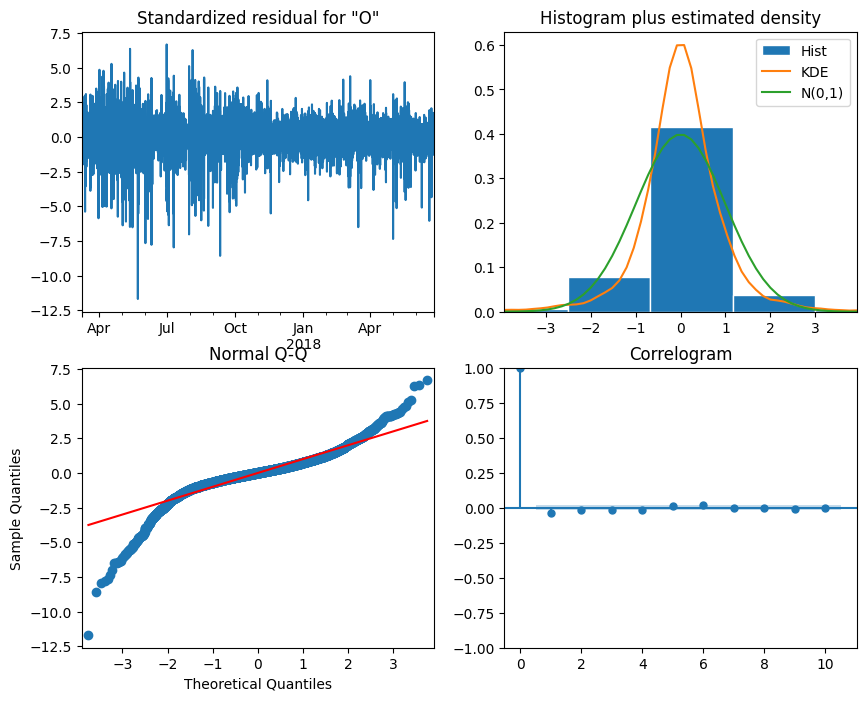

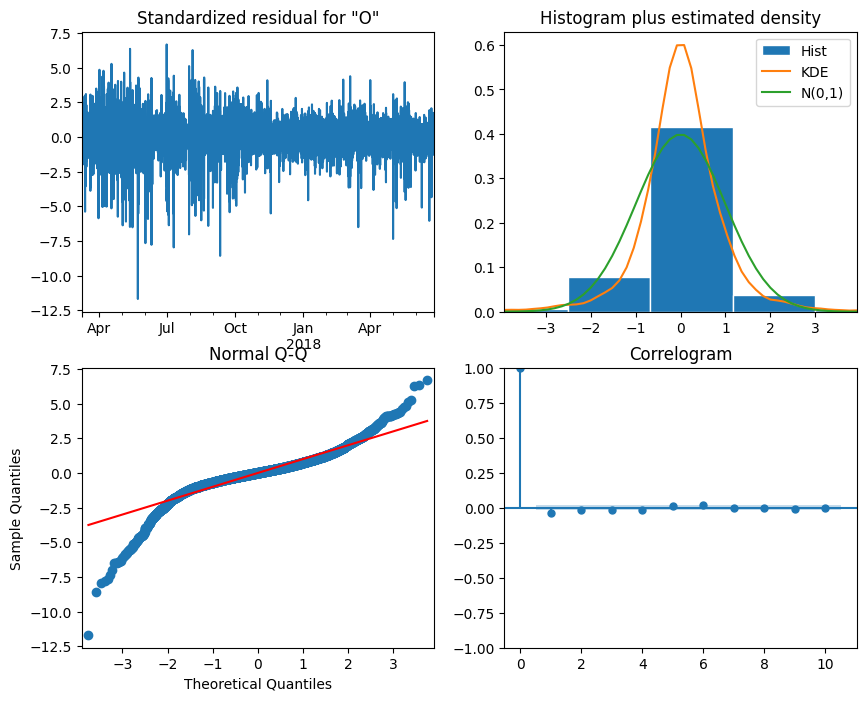

In [29]:
print(pd.DataFrame(final_model_AIC.resid).describe().T)
final_model_AIC.plot_diagnostics(figsize=(10, 8))

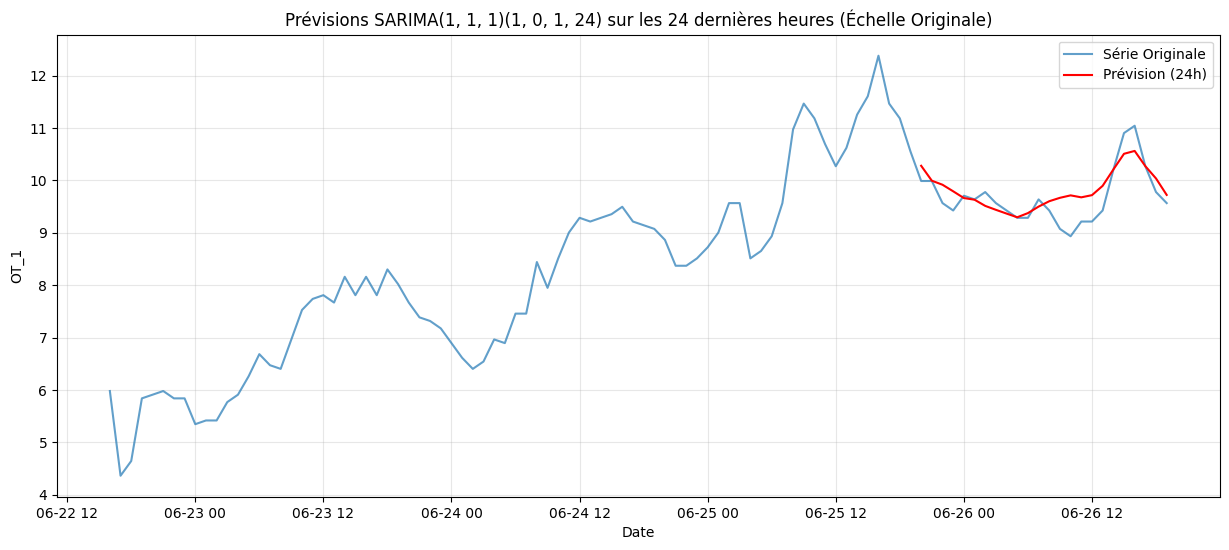

--- Performances sur 24h ---
MAE	: 0.2518
RMSE	: 0.3305
MAPE	: 2.63%


In [30]:
forecast_diff_AIC = final_model_AIC.forecast(steps=testsize)


# ********** PLOT ***********
plt.figure(figsize=(15, 6))

plt.plot(df1.index[-100:], df1['OT_1'][-100:], label='Série Originale', color='tab:blue', alpha=0.7)
plt.plot(forecast_diff_AIC.index, forecast_diff_AIC, label=f'Prévision ({testsize}h)', color='red', linewidth=1.5)

plt.title(f"Prévisions SARIMA(1, 1, 1)(1, 0, 1, 24) sur les {testsize} dernières heures (Échelle Originale)")
plt.xlabel("Date")
plt.ylabel("OT_1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


rmse_AIC = np.sqrt(mean_squared_error(df1.iloc[-testsize:], forecast_diff_AIC))
mae_AIC  = mean_absolute_error(df1.iloc[-testsize:], forecast_diff_AIC)
mape_AIC = np.mean(np.abs((df1.iloc[-testsize:]['OT_1'] - forecast_diff_AIC) / df1.iloc[-testsize:]['OT_1'])) * 100


print(f"--- Performances sur {testsize}h ---")
print(f"MAE\t: {mae_AIC:.4f}")
print(f"RMSE\t: {rmse_AIC:.4f}")
print(f"MAPE\t: {mape_AIC:.2f}%")

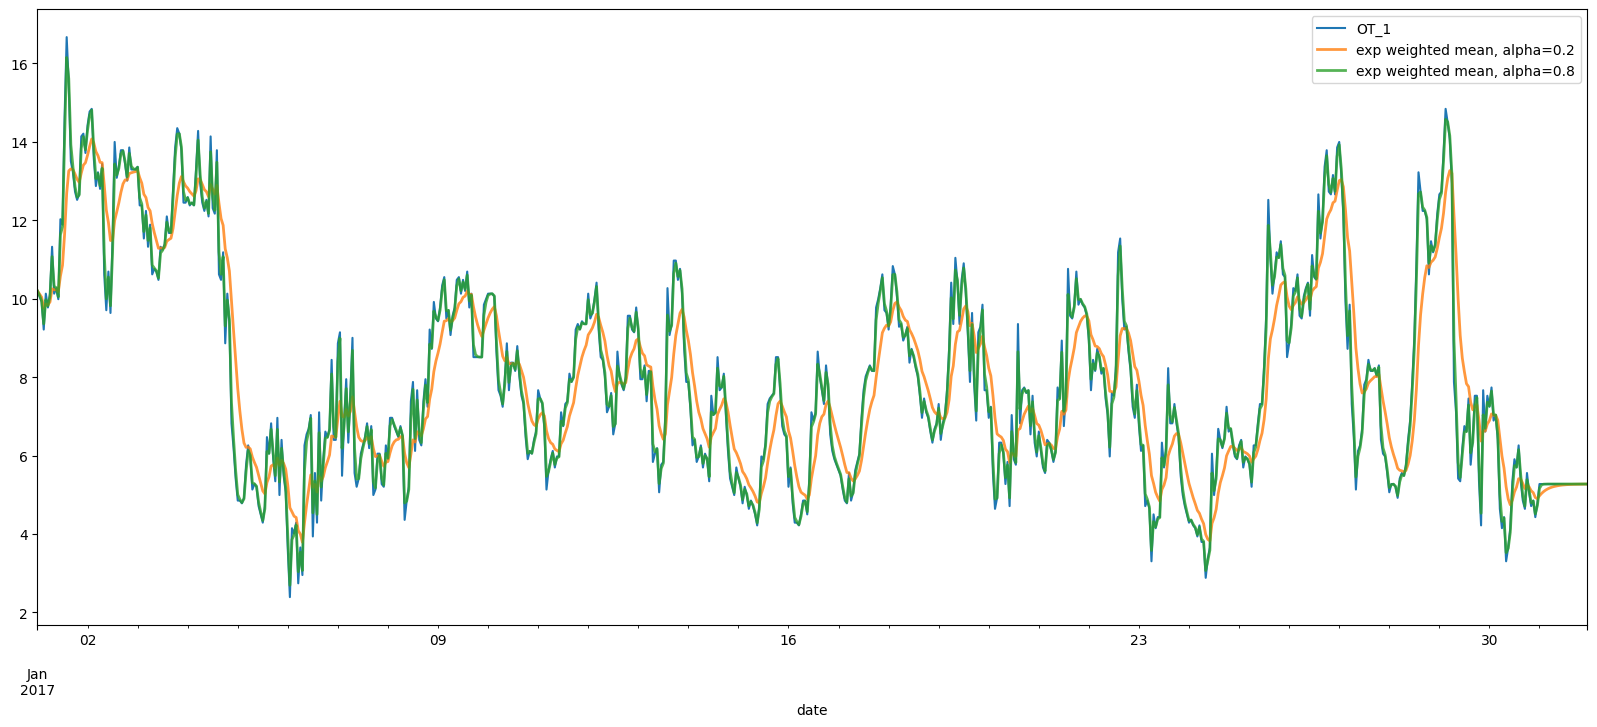

In [31]:
#lissage exponentiel
plt.figure(figsize=(20,8))
df1.loc['2017-01', 'OT_1'].plot()
for i in np.arange(0.2,1,0.6):
    df1.loc['2017-01', 'OT_1'].ewm(alpha=round(i,2)).mean().plot(label=f'exp weighted mean, alpha={round(i,2)}', lw=2, alpha=0.8)
plt.legend()
plt.show()

# Analyse de la Saisonnalité et Décomposition

<Axes: xlabel='mean', ylabel='std'>

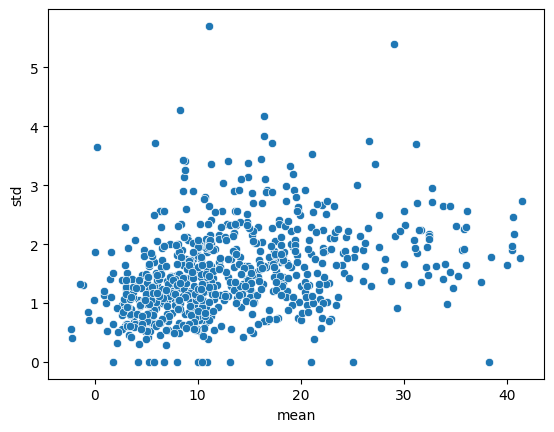

In [32]:
# Modèle multiplicatif ou additif ? Méthode de Buys-Ballot
df_buys_ballot = df1.resample('D').agg(['mean','std'])
sns.scatterplot(x=df_buys_ballot['OT_1']['mean'], y=df_buys_ballot['OT_1']['std'])

In [33]:
import statsmodels.api as sm

#si le modele est justifié, alors multiplicatif

X = df_buys_ballot['OT_1']['mean']
y = df_buys_ballot['OT_1']['std']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    std   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     102.1
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.55e-22
Time:                        17:19:50   Log-Likelihood:                -770.55
No. Observations:                 726   AIC:                             1545.
Df Residuals:                     724   BIC:                             1554.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0920      0.049     22.417      0.0

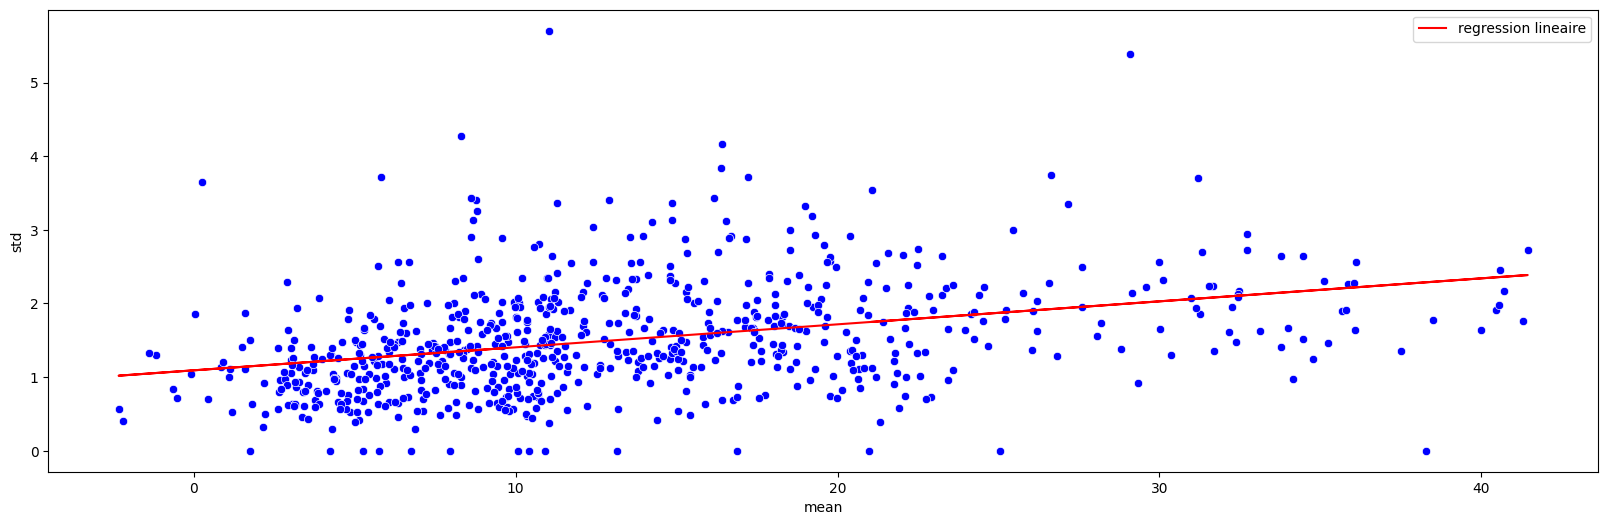

In [34]:
df_buys_ballot["pred_ecart_type"] = model.predict(X)

plt.figure(figsize=(20,6))
sns.scatterplot(x=df_buys_ballot['OT_1']['mean'], y=df_buys_ballot['OT_1']['std'], color="blue")
plt.plot(df_buys_ballot['OT_1']['mean'], df_buys_ballot["pred_ecart_type"], color="red", label="regression lineaire")
plt.legend()
plt.show()

# Analyse de la Volatilité (Variance)

Le transformateur chauffe-t-il de manière stable ou par pics brutaux ?Indicateur : Coefficient de Variation ($CV = \frac{\sigma}{\mu}$).Interprétation : Un $CV$ élevé sur les colonnes de charge (HUFL, HULL) indique des sauts de consommation qui vont impacter brutalement la température de l'huile (OT).

# Indicateurs statistiques

Indicateur,Utilité pour le modèle,Observation attendue sur ETT

Kurtosis,Mesure les valeurs extrêmes.,Un Kurtosis élevé = beaucoup d'anomalies de tension.

Skewness,Asymétrie de la distrib.,"Si positif, le transformateur surchauffe plus souvent qu'il ne refroidit."

Corrélation Croisée,Lien entre HUFL et OT.,Décalage (Lag) : Combien de temps après un pic de charge l'huile chauffe-t-elle ?

# Analyse des "Lags" (Le décalage temporel)

C'est l'observation la plus pertinente pour toi : La température de l'huile (OT) ne monte pas instantanément quand la charge électrique (HUFL) augmente. Il y a une inertie thermique.Action : Calcule la corrélation entre HUFL(t-k) et OT(t).Résultat : Si la corrélation est maximale à $k=3$, cela veut dire qu'il y a un délai de 3 heures (pour ETTh) avant que la charge n'impacte la température. Ton modèle doit impérativement intégrer ce décalage.